# Exploratory Data Analysis (EDA) of S&P 500 Stock Data

## Introduction
This notebook performs **Exploratory Data Analysis (EDA)** on the **S&P 500 stock data** dataset.  
The goal is to understand the structure of the dataset, inspect trends, check for missing values, study stock price behavior, and generate insights using visualizations.

## Objectives
- Load and inspect the dataset
- Understand the columns and data types
- Check for missing values and duplicates
- Explore the distribution of stock prices and trading volume
- Analyze stock trends over time
- Compute daily returns and volatility
- Study correlations among selected companies
- Summarize key insights

## Dataset
The dataset contains historical stock data for companies in the S&P 500 index.  
Each row represents a stock’s daily trading data.

## Expected Columns
- **date**: Trading date
- **open**: Opening stock price
- **high**: Highest stock price of the day
- **low**: Lowest stock price of the day
- **close**: Closing stock price
- **volume**: Number of shares traded
- **Name**: Stock ticker/company symbol

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

## 1. Load the Dataset
In Kaggle, dataset paths may vary slightly depending on the folder name.  
The following code automatically finds the main CSV file.

In [8]:
# # Automatically locate the dataset file inside /kaggle/input
# csv_path = "all_stocks_5yr.csv"
# csv_files = list(input_path.rglob("all_stocks_5yr.csv"))

# if not csv_files:
#     raise FileNotFoundError("Could not find 'all_stocks_5yr.csv' inside /kaggle/input")

# csv_path = csv_files[0]
# print("Dataset found at:", csv_path)

# # Load dataset
# df = pd.read_csv(csv_path)

# # Display first 5 rows
# df.head()

import pandas as pd

csv_path = "all_stocks_5yr.csv"
df = pd.read_csv(csv_path)

df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


## 2. Basic Overview
We first inspect the dataset’s shape, columns, data types, and a general summary.

In [11]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# General info
print("\nDataset Info:")
df.info()

Shape of dataset: (619040, 7)

Columns:
['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

Data types:
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


In [12]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
open,619029.0,8.302333e+01,9.737877e+01,1.62,40.220,62.59,94.37,2.044000e+03
high,619032.0,8.377831e+01,9.820752e+01,1.69,40.620,63.15,95.18,2.067990e+03
low,619032.0,8.225610e+01,9.650742e+01,1.50,39.830,62.02,93.54,2.035110e+03
close,619040.0,8.304376e+01,9.738975e+01,1.59,40.245,62.62,94.41,2.049000e+03
volume,619040.0,4.321823e+06,8.693610e+06,0.00,1070320.500,2082093.50,4284509.25,6.182376e+08


## 3. Data Cleaning and Preprocessing
We will:
- Convert the `date` column to datetime format
- Check for missing values
- Check for duplicate rows
- Sort values by stock name and date

In [13]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort data
df = df.sort_values(["Name", "date"]).reset_index(drop=True)

# Missing values
missing_values = df.isnull().sum()

# Duplicates
duplicate_rows = df.duplicated().sum()

print("Missing values:\n")
print(missing_values)

print("\nNumber of duplicate rows:", duplicate_rows)

Missing values:

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

Number of duplicate rows: 0


In [14]:
# Remove duplicates if any
df = df.drop_duplicates()

# Confirm shape after cleaning
print("Shape after cleaning:", df.shape)

# Display cleaned data
df.head()

Shape after cleaning: (619040, 7)


,date,open,high,low,close,volume,Name
0,2013-02-08,45.07,45.35,45.00,45.08,1824755,A
1,2013-02-11,45.17,45.18,44.45,44.60,2915405,A
2,2013-02-12,44.81,44.95,44.50,44.62,2373731,A
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A


## 4. Dataset-Level Exploration
Let us explore:
- Total number of companies
- Date range covered
- Number of observations per company

In [15]:
num_companies = df["Name"].nunique()
date_min = df["date"].min()
date_max = df["date"].max()

print("Number of unique companies:", num_companies)
print("Date range:", date_min.date(), "to", date_max.date())
print("Total observations:", len(df))

Number of unique companies: 505
Date range: 2013-02-08 to 2018-02-07
Total observations: 619040


In [16]:
# Observations per company
company_counts = df["Name"].value_counts()

print("Top 10 companies by number of records:")
print(company_counts.head(10))

Top 10 companies by number of records:
Name
ZTS     1259
A       1259
AAL     1259
AAP     1259
AAPL    1259
ABBV    1259
ABC     1259
ABT     1259
ACN     1259
WMT     1259
Name: count, dtype: int64


## 5. Univariate Analysis
We now study the distribution of:
- Closing prices
- Opening prices
- Trading volume

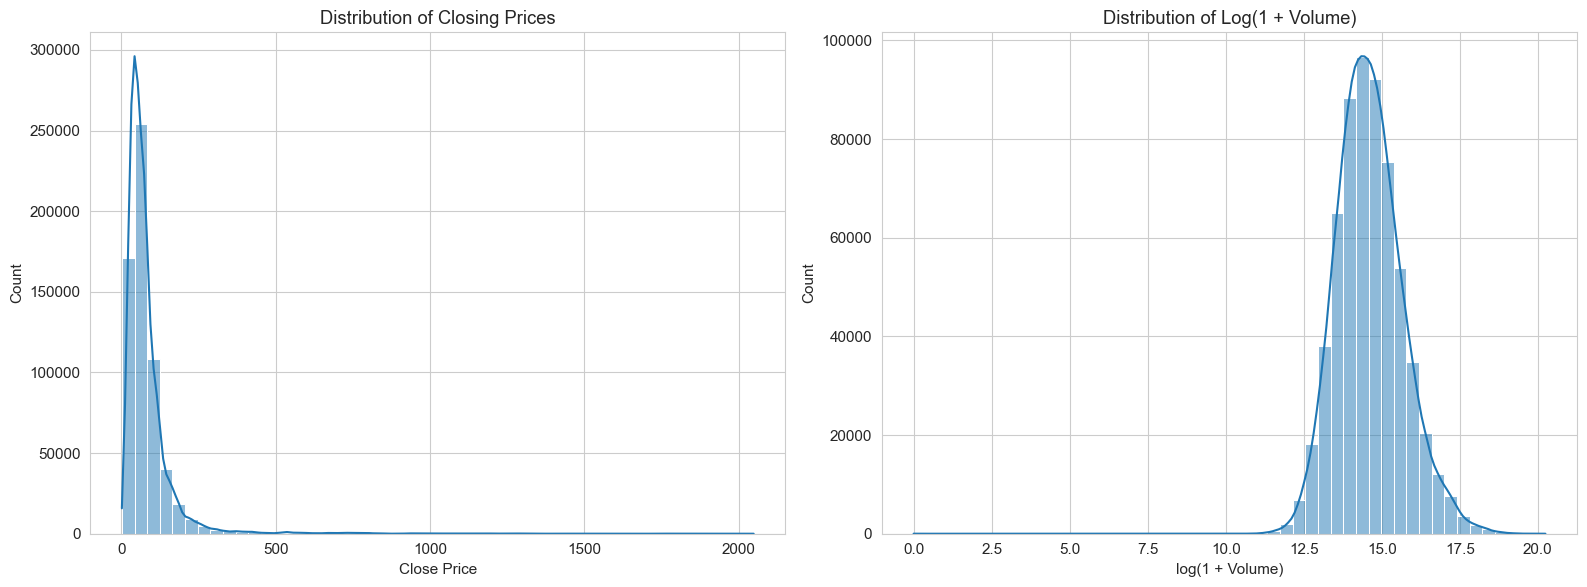

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df["close"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Closing Prices")
axes[0].set_xlabel("Close Price")

sns.histplot(np.log1p(df["volume"]), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Log(1 + Volume)")
axes[1].set_xlabel("log(1 + Volume)")

plt.tight_layout()
plt.show()

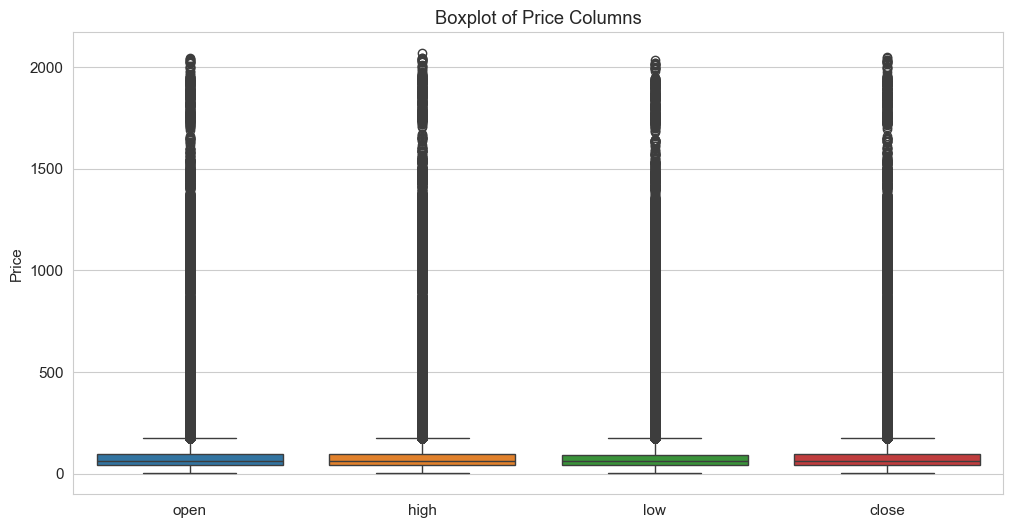

In [19]:
# Boxplots for price columns
price_cols = ["open", "high", "low", "close"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[price_cols])
plt.title("Boxplot of Price Columns")
plt.ylabel("Price")
plt.show()

## 6. Company-Wise Summary Statistics
We will compute summary statistics for each company:
- Average closing price
- Standard deviation of closing price
- Average trading volume
- Number of trading days

In [20]:
company_summary = df.groupby("Name").agg(
    trading_days=("date", "count"),
    avg_open=("open", "mean"),
    avg_close=("close", "mean"),
    std_close=("close", "std"),
    avg_volume=("volume", "mean"),
    min_close=("close", "min"),
    max_close=("close", "max")
).sort_values("avg_close", ascending=False)

company_summary.head(10)

,trading_days,avg_open,avg_close,std_close,avg_volume,min_close,max_close
Name,,,,,,,
PCLN,1259,1312.678483,1312.873538,320.533473,6.302927e+05,671.54,2049.00
GOOG,975,725.364168,725.403353,166.420529,1.808414e+06,492.55,1175.84
GOOGL,1259,682.357041,682.233847,187.573892,2.457501e+06,383.34,1187.56
AZO,1259,619.670616,619.703654,130.749597,3.157944e+05,373.61,815.98
AMZN,1259,576.867264,576.880041,282.500395,3.730465e+06,248.23,1450.89
CMG,1259,493.331998,493.256008,130.280624,8.205795e+05,268.70,757.77
REGN,1259,381.861515,381.833100,94.069345,8.786886e+05,158.42,592.40
MTD,1259,356.100826,356.297498,131.397220,1.703652e+05,197.91,692.30
BLK,1259,348.577911,348.628967,62.336884,6.397376e+05,236.15,593.26


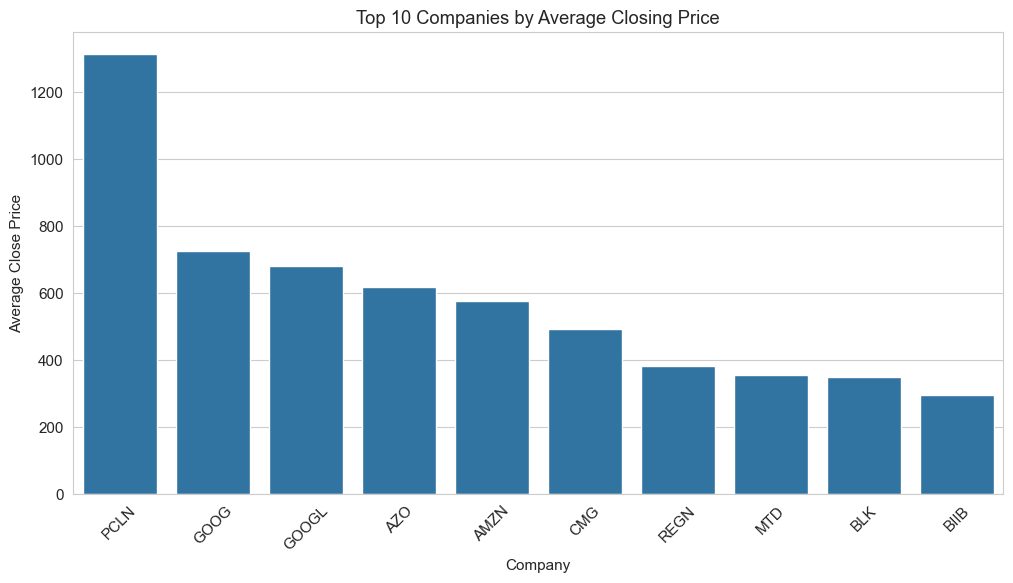

In [21]:
# Top 10 companies by average closing price
top_avg_close = company_summary.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_avg_close.index, y=top_avg_close["avg_close"])
plt.title("Top 10 Companies by Average Closing Price")
plt.xlabel("Company")
plt.ylabel("Average Close Price")
plt.xticks(rotation=45)
plt.show()

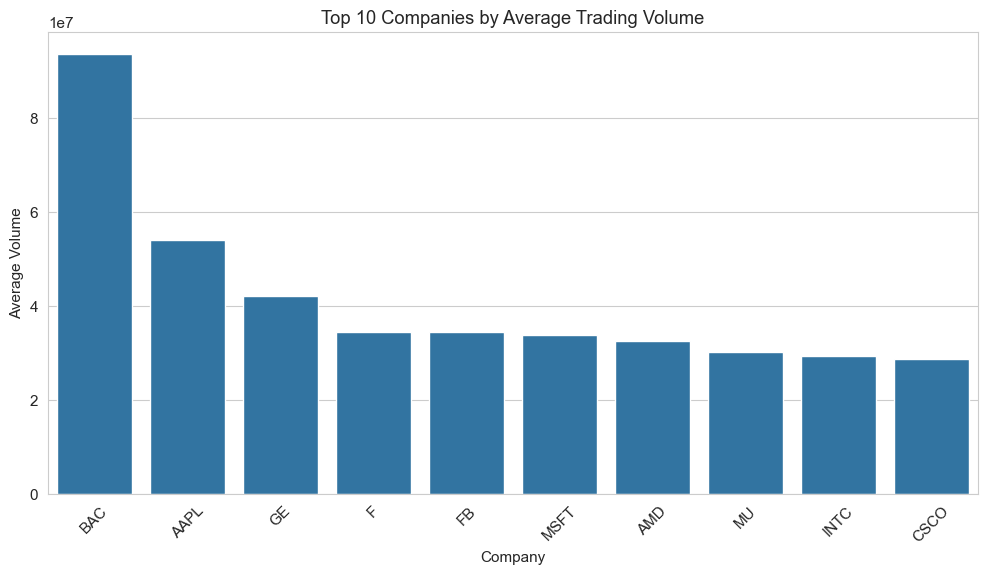

In [22]:
# Top 10 companies by average trading volume
top_volume = company_summary.sort_values("avg_volume", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_volume.index, y=top_volume["avg_volume"])
plt.title("Top 10 Companies by Average Trading Volume")
plt.xlabel("Company")
plt.ylabel("Average Volume")
plt.xticks(rotation=45)
plt.show()

## 7. Time Series Analysis of Selected Stocks
Visualizing all 500 companies together would be too crowded.  
So we select a few well-known companies and analyze their closing prices over time.

In [23]:
# Preferred companies to visualize
preferred_stocks = ["AAPL", "AMZN", "GOOGL", "MSFT", "META"]

# Keep only those present in dataset
selected_stocks = [stock for stock in preferred_stocks if stock in df["Name"].unique()]

# If some are not available, choose first 4 available companies from dataset
if len(selected_stocks) < 4:
    selected_stocks = list(df["Name"].unique()[:4])

print("Selected stocks:", selected_stocks)

Selected stocks: ['AAPL', 'AMZN', 'GOOGL', 'MSFT']


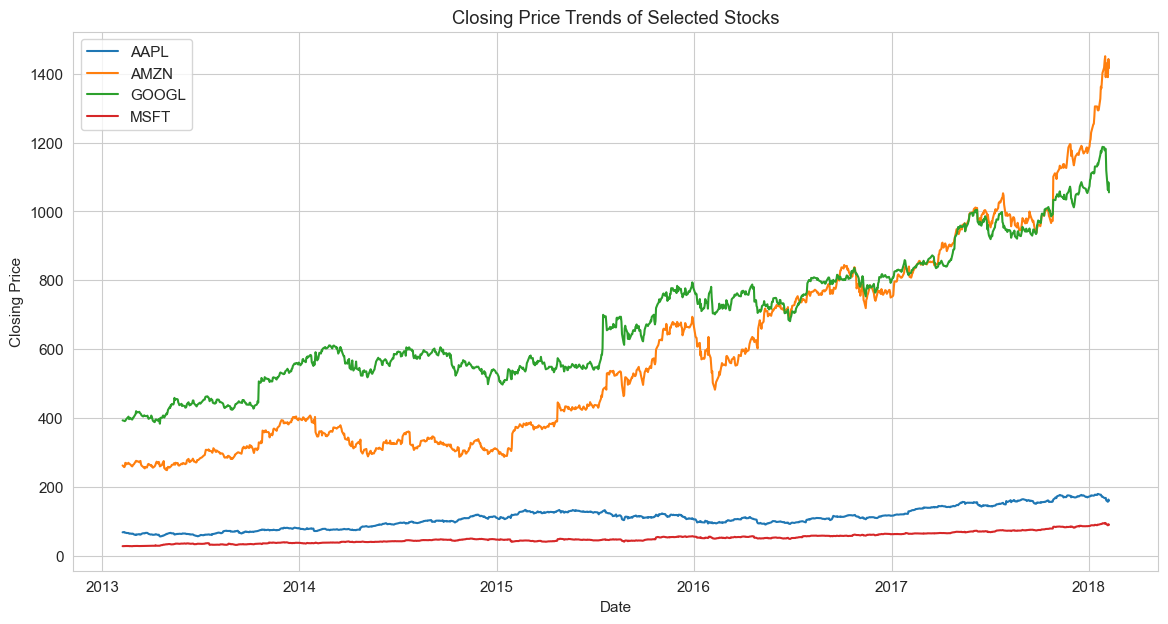

In [24]:
plt.figure(figsize=(14, 7))

for stock in selected_stocks:
    stock_data = df[df["Name"] == stock]
    plt.plot(stock_data["date"], stock_data["close"], label=stock)

plt.title("Closing Price Trends of Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

## 8. Moving Average Analysis
Moving averages help smooth short-term fluctuations and show longer-term trends.
We will compute:
- 20-day moving average
- 50-day moving average

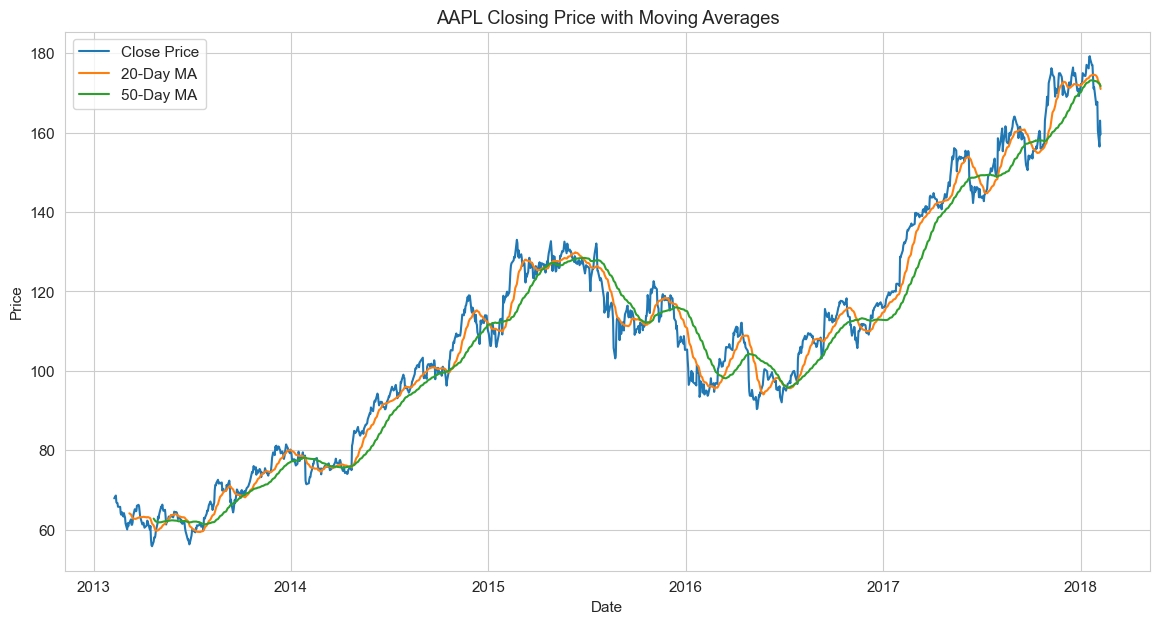

In [25]:
# Choose one stock for moving average analysis
stock_for_ma = selected_stocks[0]
stock_df = df[df["Name"] == stock_for_ma].copy()

stock_df["MA_20"] = stock_df["close"].rolling(window=20).mean()
stock_df["MA_50"] = stock_df["close"].rolling(window=50).mean()

plt.figure(figsize=(14, 7))
plt.plot(stock_df["date"], stock_df["close"], label="Close Price")
plt.plot(stock_df["date"], stock_df["MA_20"], label="20-Day MA")
plt.plot(stock_df["date"], stock_df["MA_50"], label="50-Day MA")

plt.title(f"{stock_for_ma} Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## 9. Daily Returns Analysis
Daily return shows the percentage change in closing price from one day to the next.

Formula:

\[
\text{Daily Return} = \frac{\text{Close}_t - \text{Close}_{t-1}}{\text{Close}_{t-1}}
\]

In [26]:
# Calculate daily return for each company
df["daily_return"] = df.groupby("Name")["close"].pct_change()

# Display sample
df[["date", "Name", "close", "daily_return"]].head(10)

,date,Name,close,daily_return
0,2013-02-08,A,45.08,NaN
1,2013-02-11,A,44.60,-0.010648
2,2013-02-12,A,44.62,0.000448
3,2013-02-13,A,44.75,0.002913
4,2013-02-14,A,44.58,-0.003799
5,2013-02-15,A,42.25,-0.052266
6,2013-02-19,A,43.01,0.017988
7,2013-02-20,A,42.24,-0.017903
8,2013-02-21,A,41.63,-0.014441
9,2013-02-22,A,41.80,0.004084


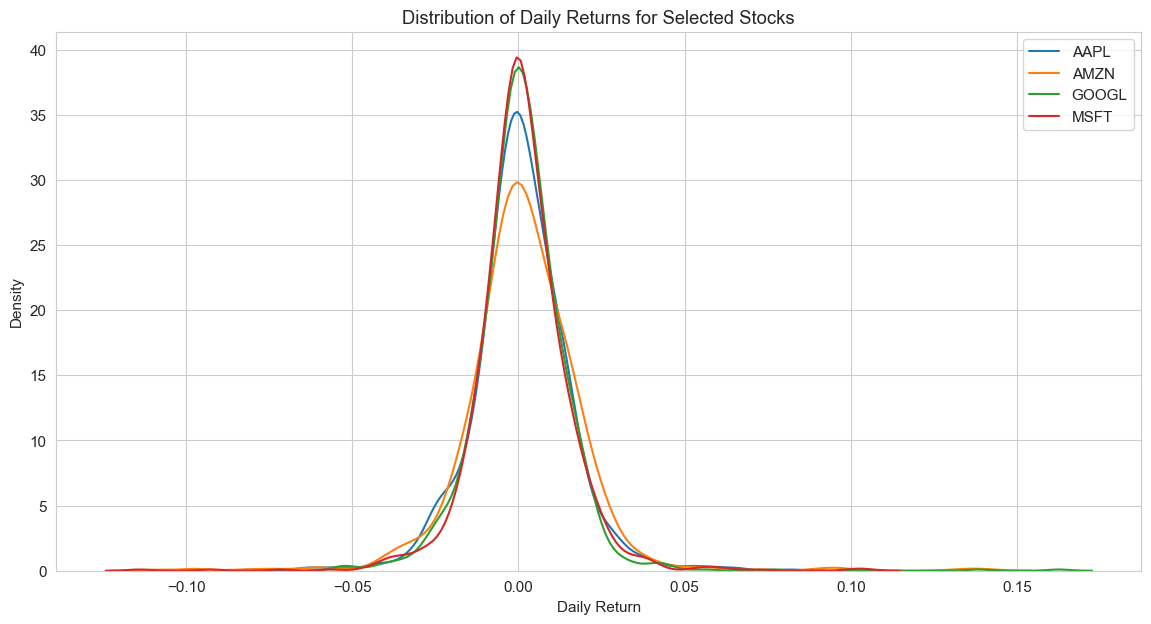

In [27]:
# Plot return distributions for selected stocks
plt.figure(figsize=(14, 7))

for stock in selected_stocks:
    stock_returns = df[df["Name"] == stock]["daily_return"].dropna()
    sns.kdeplot(stock_returns, label=stock, fill=False)

plt.title("Distribution of Daily Returns for Selected Stocks")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.show()

## 10. Volatility Analysis
Volatility measures how much a stock’s returns fluctuate over time.  
A common measure is the standard deviation of daily returns.

In [28]:
volatility = df.groupby("Name")["daily_return"].std().sort_values(ascending=False)

volatility_df = volatility.head(15).reset_index()
volatility_df.columns = ["Name", "Volatility"]

volatility_df

,Name,Volatility
0,CHK,0.041658
1,AMD,0.037784
2,BHGE,0.035219
3,FCX,0.034123
4,LNT,0.033373
5,VRTX,0.032103
6,INCY,0.029777
7,MRO,0.029739
8,WMB,0.029559
9,UA,0.028596


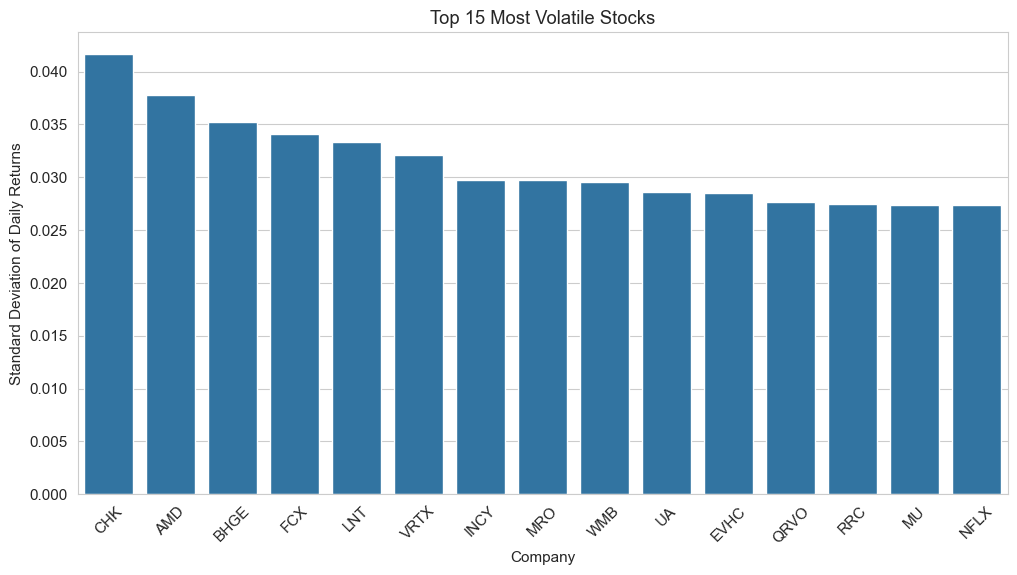

In [29]:
plt.figure(figsize=(12, 6))
sns.barplot(data=volatility_df, x="Name", y="Volatility")
plt.title("Top 15 Most Volatile Stocks")
plt.xlabel("Company")
plt.ylabel("Standard Deviation of Daily Returns")
plt.xticks(rotation=45)
plt.show()

## 11. Correlation Analysis
To study relationships between stocks, we pivot the data so that:
- Rows represent dates
- Columns represent stock symbols
- Values represent closing prices

Then we calculate correlations based on daily returns.

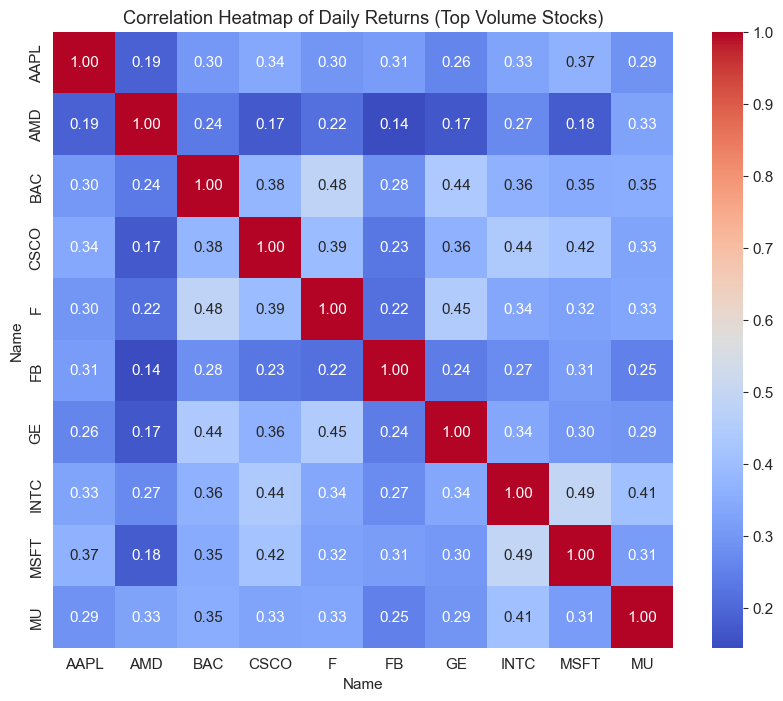

In [30]:
# Use top 10 companies by average volume for correlation study
top_corr_stocks = top_volume.index.tolist()

corr_data = df[df["Name"].isin(top_corr_stocks)].pivot(index="date", columns="Name", values="close")
corr_returns = corr_data.pct_change().dropna()

corr_matrix = corr_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Daily Returns (Top Volume Stocks)")
plt.show()

## 12. Monthly Trend Analysis
To better understand long-term trends, we can aggregate closing prices by month.

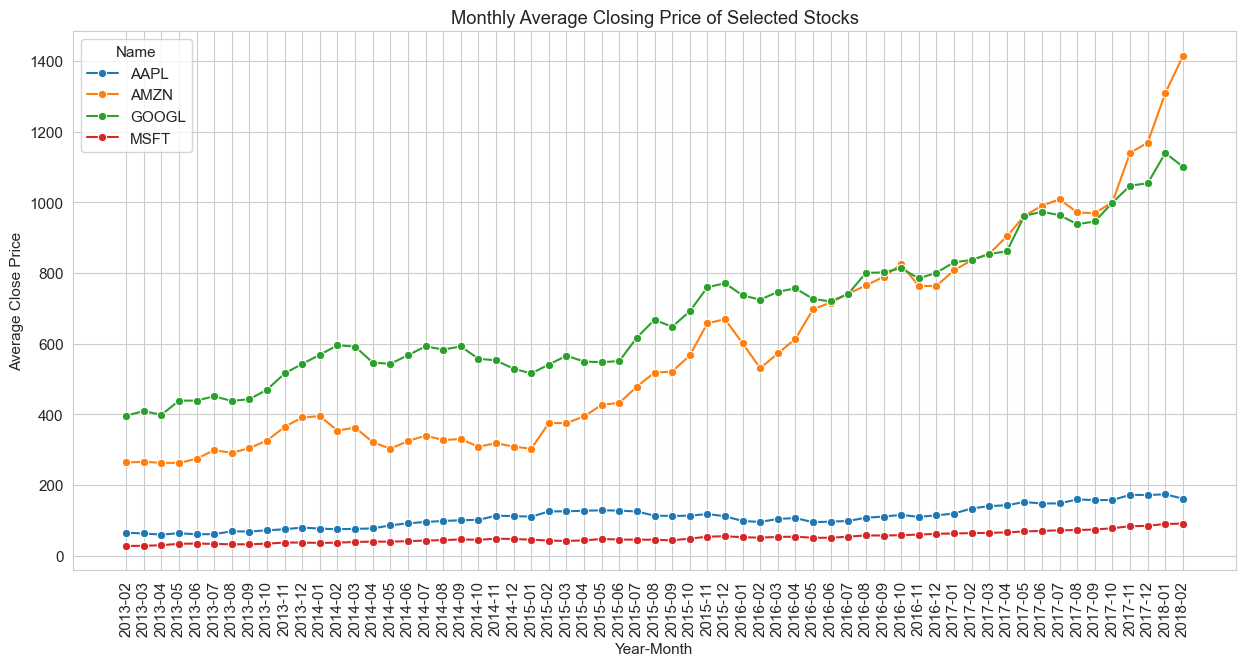

In [31]:
monthly_df = df.copy()
monthly_df["year_month"] = monthly_df["date"].dt.to_period("M")

monthly_close = (
    monthly_df[monthly_df["Name"].isin(selected_stocks)]
    .groupby(["year_month", "Name"])["close"]
    .mean()
    .reset_index()
)

monthly_close["year_month"] = monthly_close["year_month"].astype(str)

plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_close, x="year_month", y="close", hue="Name", marker="o")
plt.title("Monthly Average Closing Price of Selected Stocks")
plt.xlabel("Year-Month")
plt.ylabel("Average Close Price")
plt.xticks(rotation=90)
plt.show()

## 13. Key Findings
Based on the EDA, we can observe the following:

1. The dataset contains stock market information for many companies in the S&P 500 index.
2. The data spans multiple years of daily trading activity.
3. Closing prices and trading volumes vary greatly across companies.
4. Some companies show strong upward trends, while others fluctuate more heavily.
5. Daily returns are generally centered around zero, but extreme values indicate occasional large movements.
6. Volatility differs across companies, meaning some stocks are riskier than others.
7. Correlation analysis helps identify stocks that tend to move together.

These findings are useful for later machine learning tasks such as:
- Stock trend prediction
- Volatility forecasting
- Clustering of stocks
- Portfolio analysis

## 14. Conclusion
In this notebook, we performed Exploratory Data Analysis (EDA) on the S&P 500 stock dataset.  
We examined the dataset structure, cleaned the data, analyzed prices and volume, visualized trends, computed daily returns, studied volatility, and explored correlations.

This EDA provides a solid foundation for applying machine learning techniques such as:
- Regression for stock price prediction
- Classification for market movement
- Time series forecasting
- Clustering for grouping similar stocks

## End of Notebook

In [32]:
# Final quick summary table
summary = {
    "Total Rows": len(df),
    "Total Columns": df.shape[1],
    "Unique Companies": df["Name"].nunique(),
    "Start Date": str(df["date"].min().date()),
    "End Date": str(df["date"].max().date()),
    "Duplicate Rows Removed": int(duplicate_rows)
}

pd.DataFrame(summary.items(), columns=["Metric", "Value"])

,Metric,Value
0,Total Rows,619040
1,Total Columns,8
2,Unique Companies,505
3,Start Date,2013-02-08
4,End Date,2018-02-07
5,Duplicate Rows Removed,0


In [ ]:
# --- LSTM Training + Save (minimal reproducible example)
# This cell trains a simple LSTM for a single selected stock and saves the model and scaler.
# Run only when you want to train.
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib

# Parameters (change as needed)
symbol = 'AAPL'  # pick a ticker present in the dataset
sequence_length = 30
test_size = 0.2
epochs = 20
batch_size = 32
model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)

# Prepare data for a single symbol
df_symbol = df[df['Name'] == symbol].copy()
df_symbol = df_symbol.sort_values('date')
prices = df_symbol['close'].values.reshape(-1, 1)

# Scale prices
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

# Windowing
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(prices_scaled, sequence_length)
# Train-test split (time-based)
split_index = int((1 - test_size) * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Build model
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Callbacks
model_path = os.path.join(model_dir, f'lstm_{symbol}.h5')
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mc = ModelCheckpoint(model_path, monitor='val_loss', save_best_only=True)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[es, mc],
    verbose=1
)

# Save scaler
scaler_path = os.path.join(model_dir, f'scaler_{symbol}.bin')
joblib.dump(scaler, scaler_path)

print(f'Model saved to: {model_path}')
print(f'Scaler saved to: {scaler_path}')

# Quick evaluation on test set
y_pred = model.predict(X_test)
# inverse scale
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
print(f'Test RMSE (price units): {rmse:.4f}')

# Plot predictions vs actual (requires matplotlib)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title(f'{symbol} - Actual vs Predicted (Test)')
plt.legend()
plt.show()